# Housing Price Distribution Analysis — Northeast States, USA
### Helping Mr. Andreas Find the Right Home Within Budget

---
**Author:** Austin Silitonga  
**Dataset:** [Kaggle — Housing Prices Dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)
**Budget Target:** $2,000,000 USD  
**Goal:** Analyze housing price distributions and identify suitable homes for a family of four.


---
## 1.  Problem Background

Mr. Andreas is a 40-year-old married man with two children. He plans to relocate and purchase a house in the **Northeast States, USA**. With a total budget of **$2,000,000 USD**, he needs data-driven guidance to make an informed decision — one that balances price, size, and family-friendly features.

###  SMART Framework

| Dimension | Detail |
|-----------|--------|
| **Specific** | Analyze housing prices in Northeast States, USA for a family of four |
| **Measurable** | Measure price distribution, mean, percentiles, and feature impact |
| **Achievable** | Dataset provided by Mr. Andreas (sourced from Kaggle) |
| **Relevant** | Guides a $2M budget purchase decision for a family |
| **Time-bound** | Completed within one week |

###  Key Questions

1. How is housing price distributed across the dataset?
2. What percentage of homes fall within the $2M budget?
3. How many outliers exist, and how do they affect the analysis?
4. What is the average market price of homes in this dataset?
5. Are homes within the $2M budget suitable for a family of four?
6. Which features (stories, bedrooms, amenities) most influence price?


---
## 2.  Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# ── Visualization style ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

BUDGET      = 2_000_000
COLOR_MAIN  = '#2196F3'
COLOR_WARN  = '#FF5722'
COLOR_OK    = '#4CAF50'
COLOR_DARK  = '#263238'
PALETTE     = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## 3.  Data Loading & Initial Exploration

In [2]:
df = pd.read_csv('Housing.csv')
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)


Dataset shape: 545 rows × 13 columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
# Statistical summary for numeric columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])


,count,mean,std,min,25%,50%,75%,max
price,545.000000,4766729.247706,1870439.615657,1750000.000000,3430000.000000,4340000.000000,5740000.000000,13300000.000000
area,545.000000,5150.541284,2170.141023,1650.000000,3600.000000,4600.000000,6360.000000,16200.000000
bedrooms,545.000000,2.965138,0.738064,1.000000,2.000000,3.000000,3.000000,6.000000
bathrooms,545.000000,1.286239,0.502470,1.000000,1.000000,1.000000,2.000000,4.000000
stories,545.000000,1.805505,0.867492,1.000000,1.000000,2.000000,2.000000,4.000000
parking,545.000000,0.693578,0.861586,0.000000,0.000000,0.000000,1.000000,3.000000


In [5]:
# Check data quality
print("=== Data Quality Report ===")
print(f"Duplicate rows  : {df.duplicated().sum()}")
print(f"Missing values  :\n{df.isnull().sum()}")


=== Data Quality Report ===
Duplicate rows  : 0
Missing values  :
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


---
## 4.  Exploratory Data Analysis (EDA)

### 4.1 Categorical Feature Overview

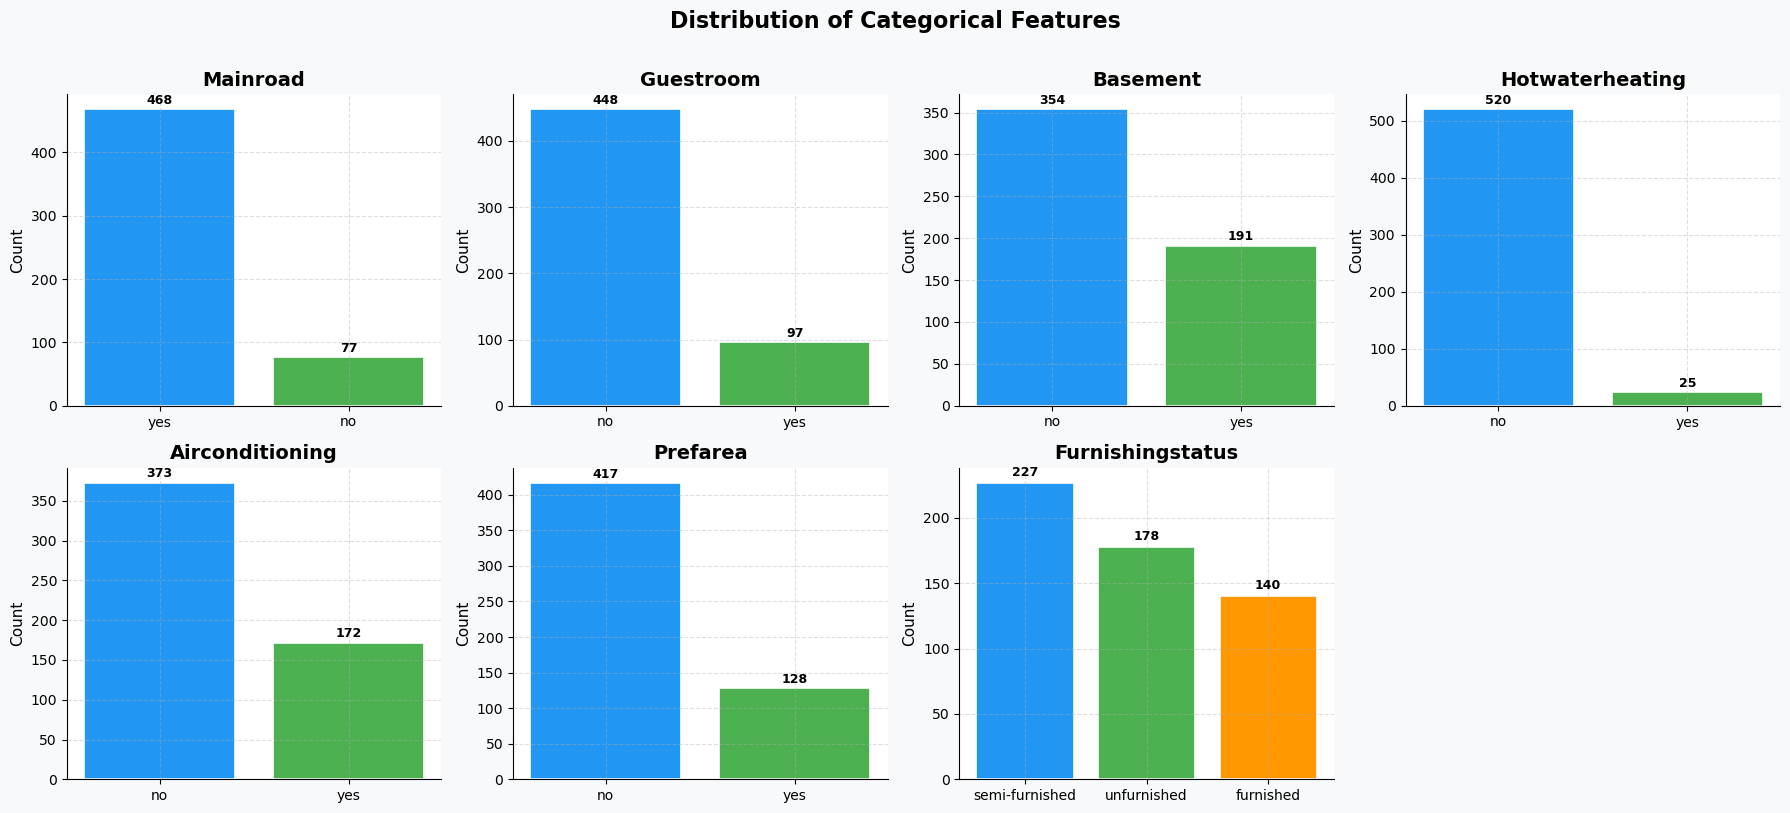

Saved: categorical_overview.png


In [6]:
cat_cols = ['mainroad','guestroom','basement','hotwaterheating',
           'airconditioning','prefarea','furnishingstatus']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color=PALETTE[:len(counts)], edgecolor='white', linewidth=1.2)
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('categorical_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: categorical_overview.png")


### 4.2 Numeric Feature Distributions

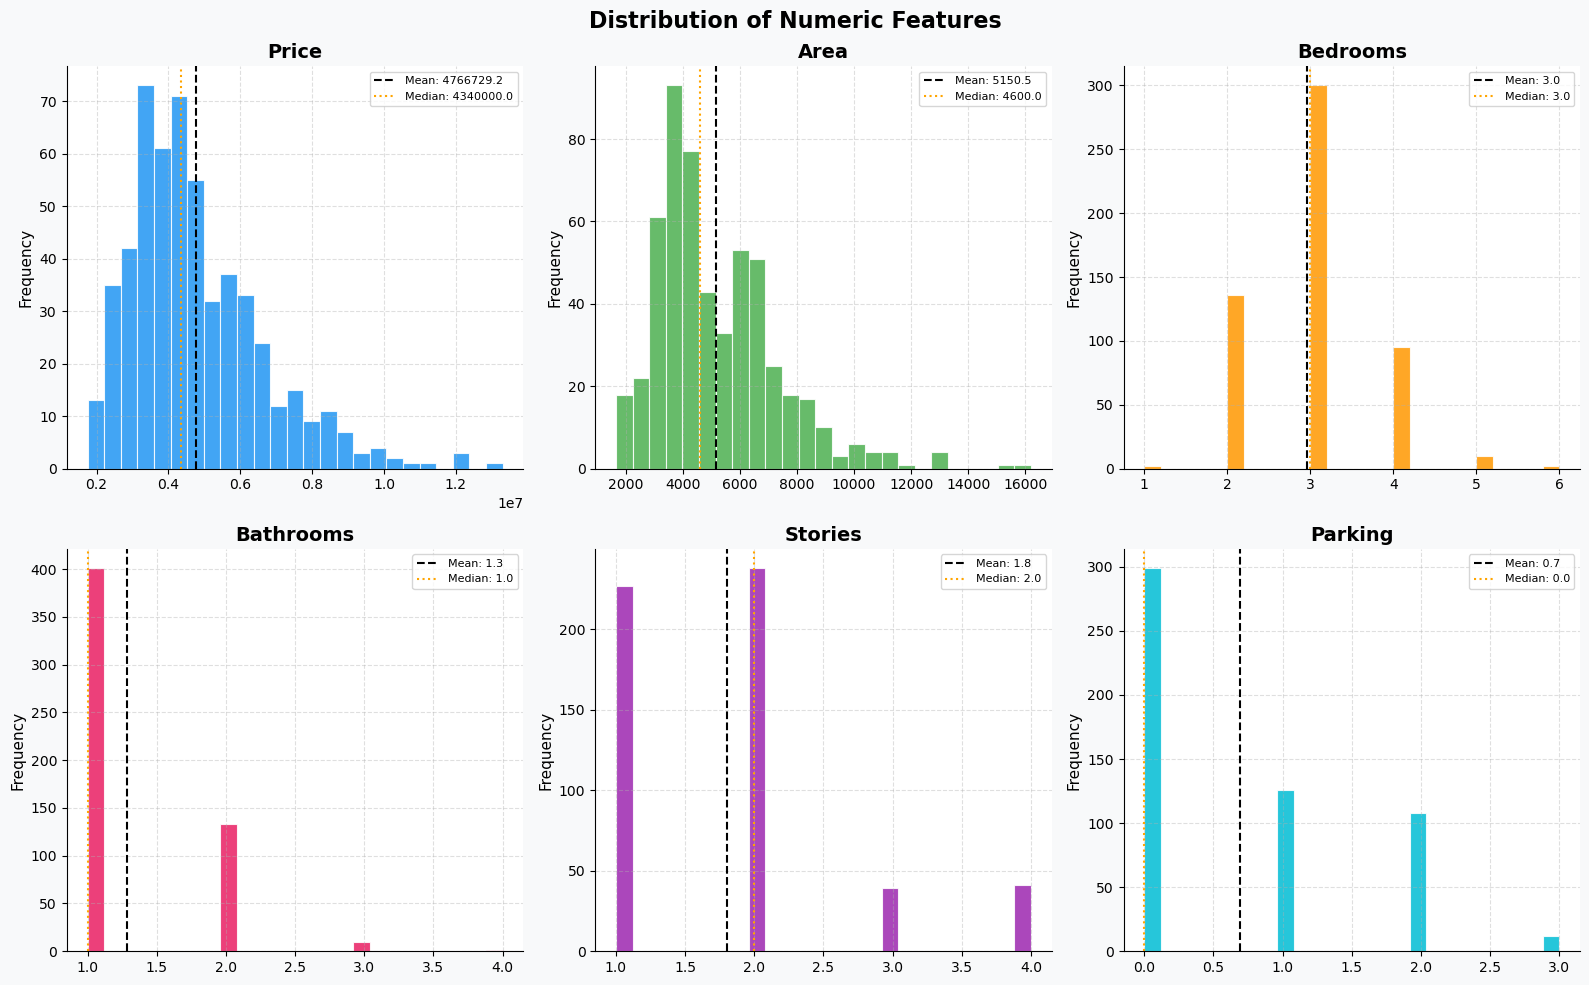

In [7]:
num_cols = ['price','area','bedrooms','bathrooms','stories','parking']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold')

for i, col in enumerate(num_cols):
    data = df[col]
    axes[i].hist(data, bins=25, color=PALETTE[i], edgecolor='white', linewidth=0.8, alpha=0.85)
    axes[i].axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(col.title(), fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5.  Price Distribution Analysis

### 5.1 Price Histogram with Budget Line

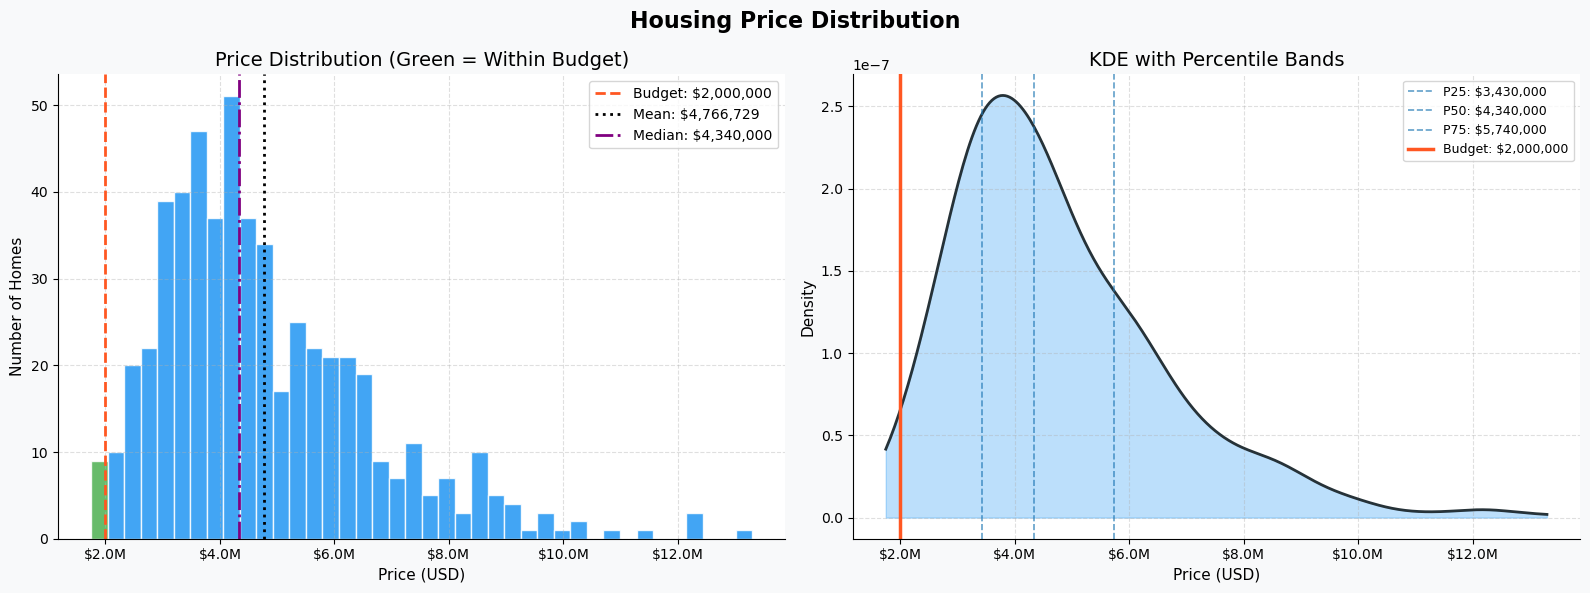

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Housing Price Distribution', fontsize=16, fontweight='bold')

# ── Left: Raw price distribution ──────────────────────────────────────────
ax = axes[0]
n, bins, patches = ax.hist(df['price'], bins=40, color=COLOR_MAIN, edgecolor='white', alpha=0.85)
# color bars beyond budget
for patch, left in zip(patches, bins[:-1]):
    if left < BUDGET:
        patch.set_facecolor(COLOR_OK)
    else:
        patch.set_facecolor(COLOR_MAIN)

ax.axvline(BUDGET,        color=COLOR_WARN, linestyle='--', linewidth=2, label=f'Budget: ${BUDGET:,.0f}')
ax.axvline(df['price'].mean(),   color='black',  linestyle=':',  linewidth=2, label=f"Mean: ${df['price'].mean():,.0f}")
ax.axvline(df['price'].median(), color='purple', linestyle='-.',  linewidth=2, label=f"Median: ${df['price'].median():,.0f}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Number of Homes')
ax.set_title('Price Distribution (Green = Within Budget)')
ax.legend()

# ── Right: KDE + percentile bands ─────────────────────────────────────────
ax2 = axes[1]
price_data = df['price'].values
kde = stats.gaussian_kde(price_data)
x_range = np.linspace(price_data.min(), price_data.max(), 300)
ax2.fill_between(x_range, kde(x_range), alpha=0.3, color=COLOR_MAIN)
ax2.plot(x_range, kde(x_range), color=COLOR_DARK, linewidth=2)

for pct in [25, 50, 75]:
    val = np.percentile(price_data, pct)
    ax2.axvline(val, linestyle='--', linewidth=1.2, alpha=0.7, label=f'P{pct}: ${val:,.0f}')
ax2.axvline(BUDGET, color=COLOR_WARN, linestyle='-', linewidth=2.5, label=f'Budget: ${BUDGET:,.0f}')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax2.set_xlabel('Price (USD)')
ax2.set_ylabel('Density')
ax2.set_title('KDE with Percentile Bands')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Budget Feasibility Summary

     BUDGET FEASIBILITY REPORT
  Total listings          :    545
  Within budget (≤$2M)    :      9  (1.7%)
  Above budget (>$2M)     :    536  (98.3%)
--------------------------------------------------
  Mean price (all)        : $   4,766,729
  Mean price (≤$2M)       : $   1,825,794
  Min price               : $   1,750,000
  Max price               : $  13,300,000


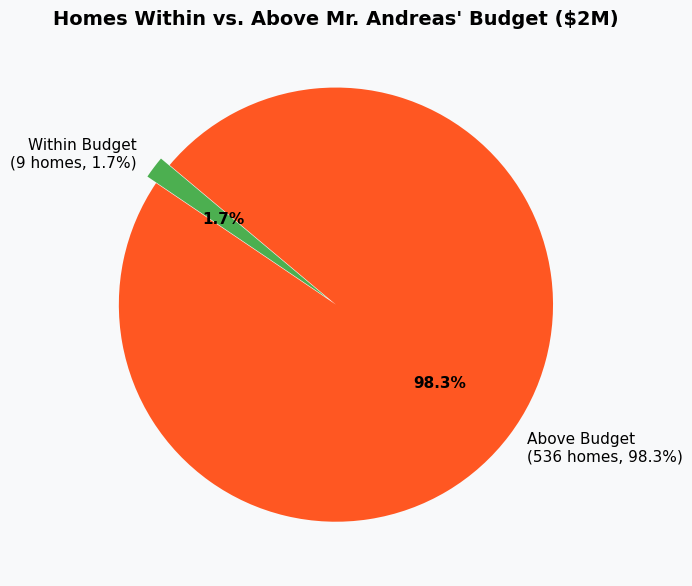

In [9]:
within  = df[df['price'] <= BUDGET]
above   = df[df['price'] >  BUDGET]
pct_within = len(within)/len(df)*100

print("=" * 50)
print("     BUDGET FEASIBILITY REPORT")
print("=" * 50)
print(f"  Total listings          : {len(df):>6}")
print(f"  Within budget (≤$2M)    : {len(within):>6}  ({pct_within:.1f}%)")
print(f"  Above budget (>$2M)     : {len(above):>6}  ({100-pct_within:.1f}%)")
print("-" * 50)
print(f"  Mean price (all)        : ${df['price'].mean():>12,.0f}")
print(f"  Mean price (≤$2M)       : ${within['price'].mean():>12,.0f}")
print(f"  Min price               : ${df['price'].min():>12,.0f}")
print(f"  Max price               : ${df['price'].max():>12,.0f}")
print("=" * 50)

# Pie chart
fig, ax = plt.subplots(figsize=(7, 7))
sizes  = [len(within), len(above)]
labels = [f'Within Budget\n({len(within)} homes, {pct_within:.1f}%)',
          f'Above Budget\n({len(above)} homes, {100-pct_within:.1f}%)']
colors = [COLOR_OK, COLOR_WARN]
explode = (0.05, 0)
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='%1.1f%%', explode=explode,
                                   startangle=140, textprops={'fontsize':11})
for at in autotexts: at.set_fontweight('bold')
ax.set_title(f"Homes Within vs. Above Mr. Andreas' Budget ($2M)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('budget_feasibility.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6.  Outlier Detection & Handling

### 6.1 Boxplot — Identifying Outliers

IQR        : $2,310,000
Lower bound: $-35,000
Upper bound: $9,205,000
Outliers   : 15 (2.8%)
Clean rows : 530


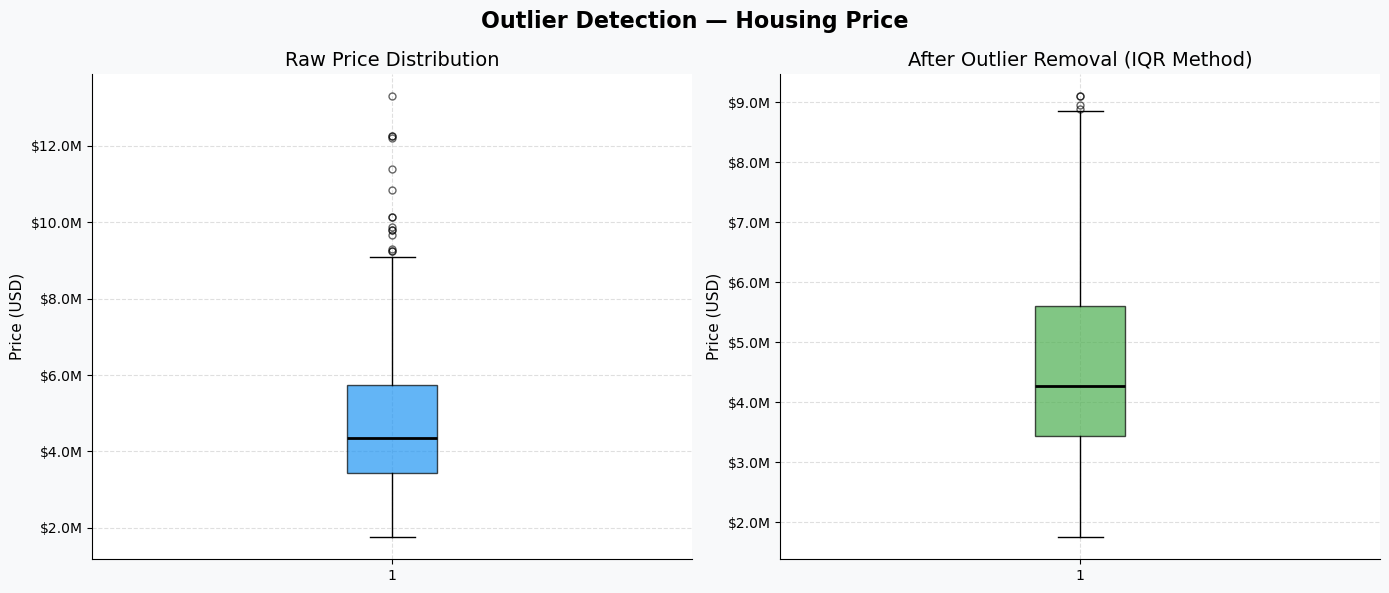

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Outlier Detection — Housing Price', fontsize=16, fontweight='bold')

# Raw
bp1 = axes[0].boxplot(df['price'], vert=True, patch_artist=True,
                       boxprops=dict(facecolor=COLOR_MAIN, alpha=0.7),
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', color=COLOR_WARN, markersize=5, alpha=0.6))
axes[0].set_title('Raw Price Distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].set_ylabel('Price (USD)')

# IQR method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers    = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
df_clean    = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(f"IQR        : ${IQR:,.0f}")
print(f"Lower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")
print(f"Outliers   : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Clean rows : {len(df_clean)}")

bp2 = axes[1].boxplot(df_clean['price'], vert=True, patch_artist=True,
                       boxprops=dict(facecolor=COLOR_OK, alpha=0.7),
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', color=COLOR_WARN, markersize=5, alpha=0.6))
axes[1].set_title('After Outlier Removal (IQR Method)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[1].set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Budget Feasibility After Outlier Removal

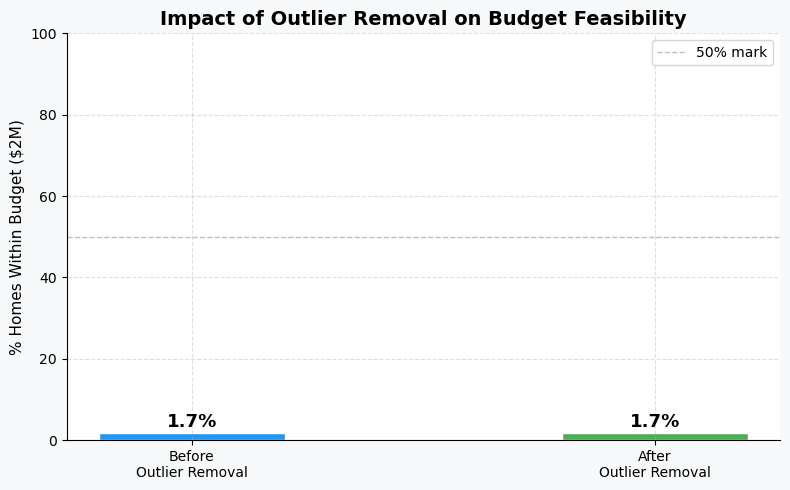

After removing outliers — 1.7% of homes are within Mr. Andreas' budget.


In [11]:
within_clean = df_clean[df_clean['price'] <= BUDGET]
pct_clean    = len(within_clean)/len(df_clean)*100

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Before\nOutlier Removal', 'After\nOutlier Removal']
pct_before = len(df[df['price'] <= BUDGET]) / len(df) * 100
pct_after  = pct_clean

bars = ax.bar(categories, [pct_before, pct_after], color=[COLOR_MAIN, COLOR_OK],
              width=0.4, edgecolor='white')
for bar, val in zip(bars, [pct_before, pct_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel('% Homes Within Budget ($2M)')
ax.set_title('Impact of Outlier Removal on Budget Feasibility', fontweight='bold', fontsize=14)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% mark')
ax.legend()
plt.tight_layout()
plt.savefig('budget_after_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"After removing outliers — {pct_clean:.1f}% of homes are within Mr. Andreas' budget.")


---
## 7.  Feature Impact on Price

### 7.1 Price vs. Area (Scatter)

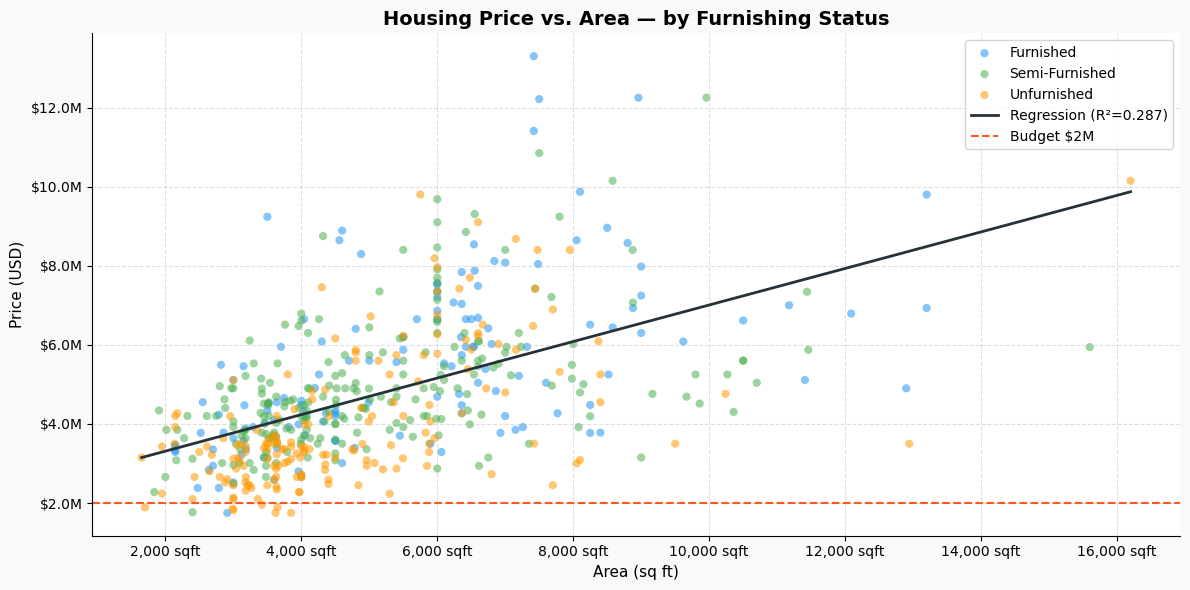

Pearson r = 0.5360  |  R² = 0.2873  |  p-value = 7.39e-42


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

color_map = {'furnished': COLOR_MAIN, 'semi-furnished': COLOR_OK, 'unfurnished': '#FF9800'}
for status, grp in df.groupby('furnishingstatus'):
    ax.scatter(grp['area'], grp['price'], c=color_map[status], alpha=0.55,
               label=status.title(), s=35, edgecolors='none')

# Regression line
m, b, r, p, _ = stats.linregress(df['area'], df['price'])
x_line = np.linspace(df['area'].min(), df['area'].max(), 200)
ax.plot(x_line, m*x_line + b, color=COLOR_DARK, linewidth=2,
        label=f'Regression (R²={r**2:.3f})')
ax.axhline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=1.5, label='Budget $2M')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f} sqft'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Price (USD)')
ax.set_title('Housing Price vs. Area — by Furnishing Status', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('price_vs_area.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pearson r = {r:.4f}  |  R² = {r**2:.4f}  |  p-value = {p:.2e}")


### 7.2 Price by Number of Bedrooms & Stories

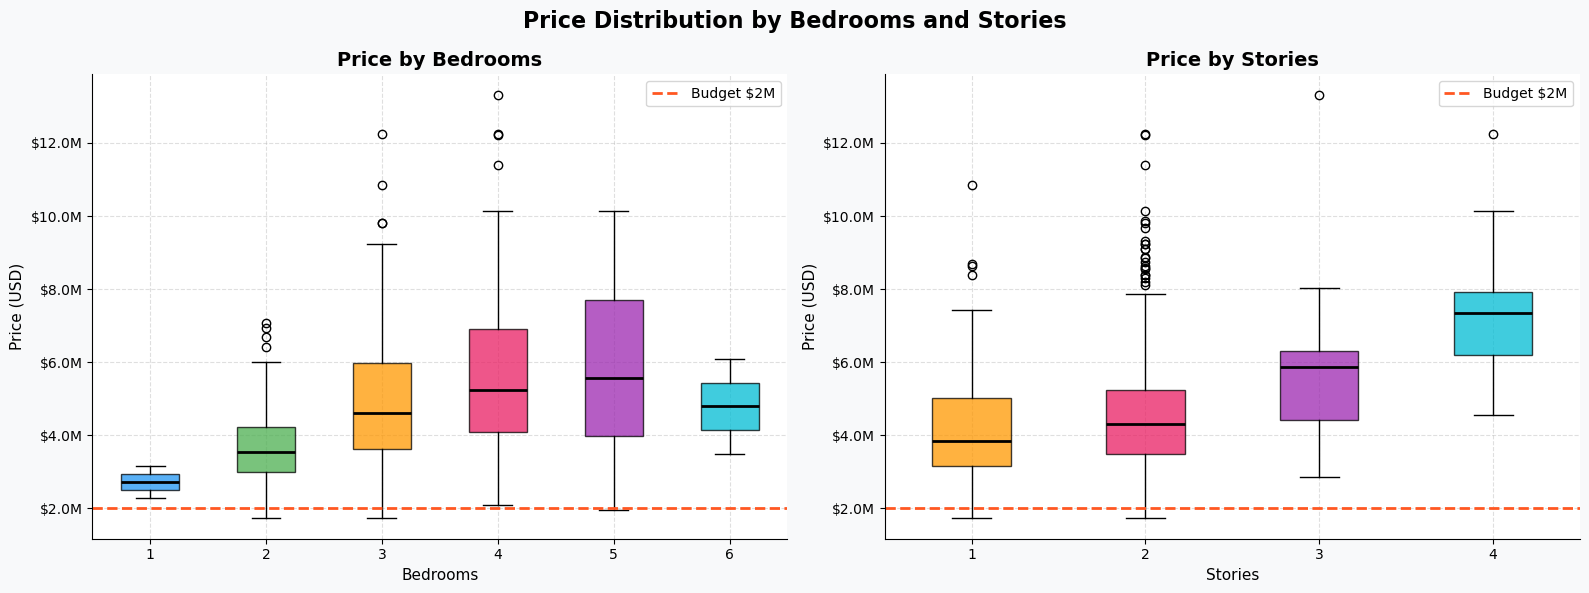

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Price Distribution by Bedrooms and Stories', fontsize=16, fontweight='bold')

for ax, col, palette_start in zip(axes, ['bedrooms','stories'], [0, 2]):
    groups = [df[df[col] == v]['price'].values for v in sorted(df[col].unique())]
    labels = [str(v) for v in sorted(df[col].unique())]
    bp = ax.boxplot(groups, patch_artist=True, labels=labels,
                    medianprops=dict(color='black', linewidth=2))
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(PALETTE[(i+palette_start) % len(PALETTE)])
        patch.set_alpha(0.75)
    ax.axhline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=2, label='Budget $2M')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
    ax.set_xlabel(col.title())
    ax.set_ylabel('Price (USD)')
    ax.set_title(f'Price by {col.title()}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('price_bedrooms_stories.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Average Price by Amenities

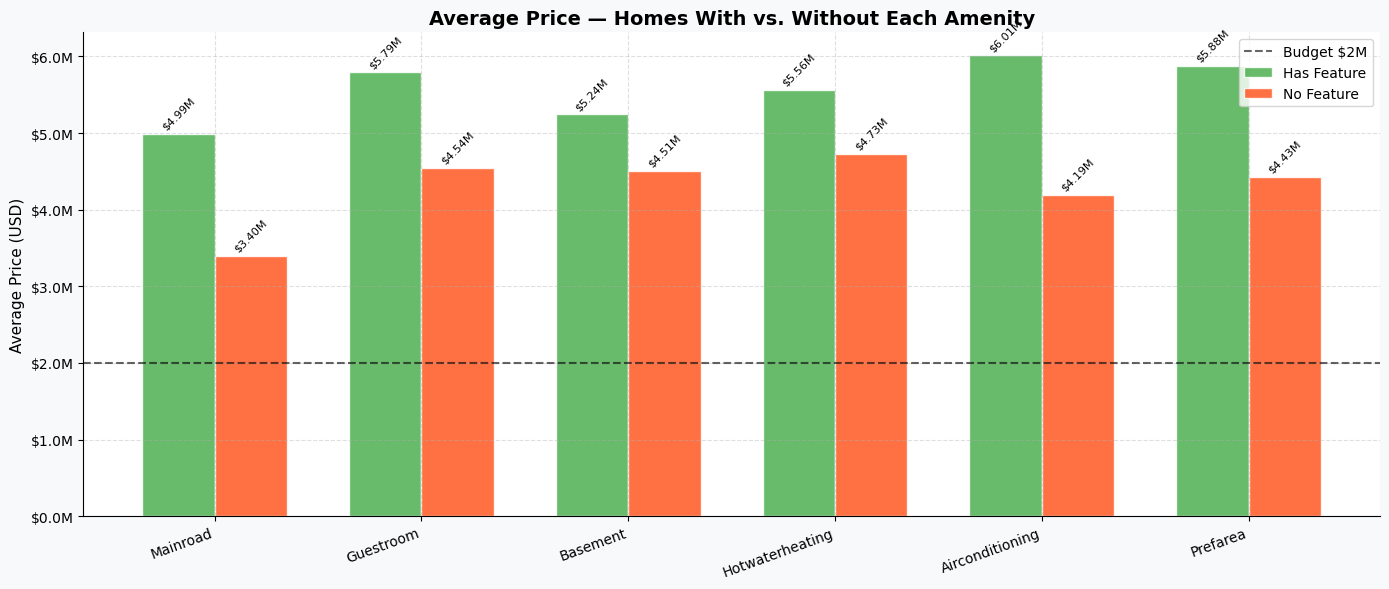

In [14]:
amenities = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
yes_means = [df[df[a]=='yes']['price'].mean() for a in amenities]
no_means  = [df[df[a]=='no']['price'].mean()  for a in amenities]

x = np.arange(len(amenities))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, yes_means, width, label='Has Feature', color=COLOR_OK,   alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, no_means,  width, label='No Feature',  color=COLOR_WARN, alpha=0.85, edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
            f'${bar.get_height()/1e6:.2f}M', ha='center', va='bottom', fontsize=8, rotation=45)

ax.axhline(BUDGET, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Budget $2M')
ax.set_xticks(x)
ax.set_xticklabels([a.replace('_',' ').title() for a in amenities], rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.set_ylabel('Average Price (USD)')
ax.set_title('Average Price — Homes With vs. Without Each Amenity', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('price_by_amenity.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.4 Price by Furnishing Status (Violin)

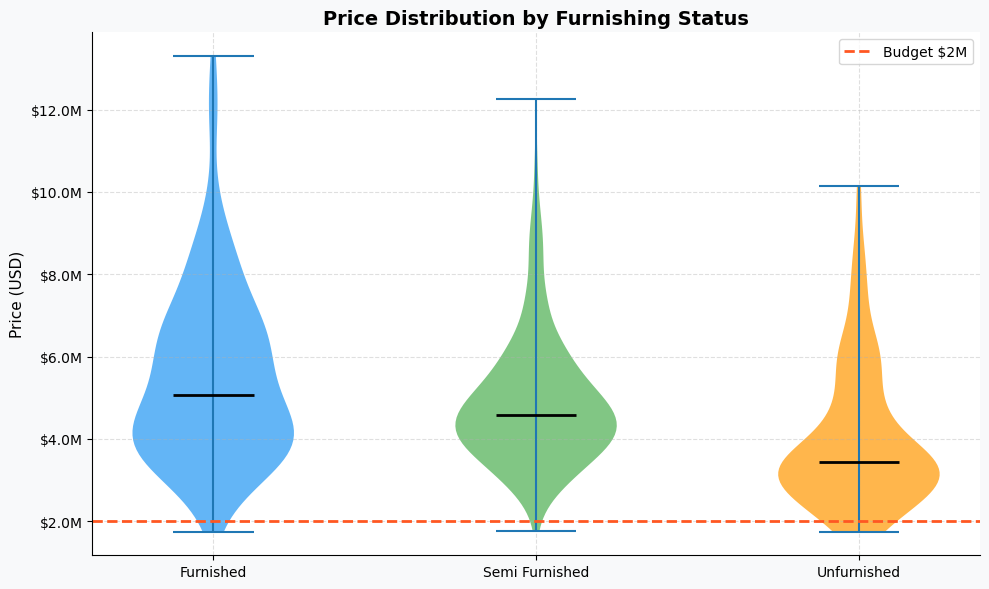

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
furn_order = ['furnished','semi-furnished','unfurnished']
furn_data  = [df[df['furnishingstatus']==f]['price'].values for f in furn_order]

parts = ax.violinplot(furn_data, positions=[1,2,3], showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax.axhline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=2, label='Budget $2M')
ax.set_xticks([1,2,3])
ax.set_xticklabels([f.replace('-',' ').title() for f in furn_order])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.set_ylabel('Price (USD)')
ax.set_title('Price Distribution by Furnishing Status', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('price_furnishing_violin.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8.  Statistical Analysis

### 8.1 One-Way ANOVA — Do Stories Significantly Affect Price?

In [16]:
groups = [df[df['stories']==s]['price'].values for s in sorted(df['stories'].unique())]
f_stat, p_val = f_oneway(*groups)
print("=== One-Way ANOVA: Price ~ Stories ===")
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_val:.6f}")
if p_val < 0.05:
    print("→ SIGNIFICANT difference in price across story levels (p < 0.05)")
else:
    print("→ No significant difference detected (p ≥ 0.05)")


=== One-Way ANOVA: Price ~ Stories ===
F-statistic : 41.7823
p-value     : 0.000000
→ SIGNIFICANT difference in price across story levels (p < 0.05)


### 8.2 Kruskal-Wallis — Furnishing Status vs. Price

In [17]:
furn_groups = [df[df['furnishingstatus']==f]['price'].values for f in furn_order]
h_stat, p_kw = kruskal(*furn_groups)
print("=== Kruskal-Wallis: Price ~ Furnishing Status ===")
print(f"H-statistic : {h_stat:.4f}")
print(f"p-value     : {p_kw:.6f}")
if p_kw < 0.05:
    print("→ SIGNIFICANT difference in price across furnishing categories (p < 0.05)")
else:
    print("→ No significant difference detected (p ≥ 0.05)")


=== Kruskal-Wallis: Price ~ Furnishing Status ===
H-statistic : 69.5829
p-value     : 0.000000
→ SIGNIFICANT difference in price across furnishing categories (p < 0.05)


### 8.3 Pearson Correlation Heatmap

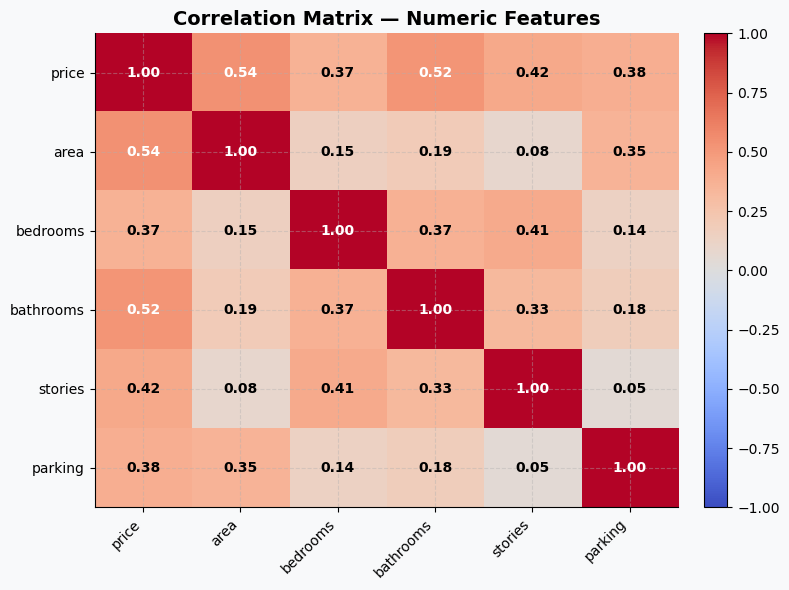

In [18]:
import numpy as np

num_df = df[['price','area','bedrooms','bathrooms','stories','parking']]
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

cols = corr.columns.tolist()
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9.  Homes Within Mr. Andreas' Budget — Deep Dive

### 9.1 Profile of Affordable Homes

In [19]:
budget_df = df[df['price'] <= BUDGET].copy()
print(f"Homes within $2M budget: {len(budget_df)}")
print()
print("=== Average Features of Affordable Homes ===")
print(f"  Average price     : ${budget_df['price'].mean():>12,.0f}")
print(f"  Average area      : {budget_df['area'].mean():>10,.1f} sq ft")
print(f"  Average bedrooms  : {budget_df['bedrooms'].mean():>10.2f}")
print(f"  Average bathrooms : {budget_df['bathrooms'].mean():>10.2f}")
print(f"  Average stories   : {budget_df['stories'].mean():>10.2f}")
print()
print("=== Categorical Features (% 'Yes') ===")
for col in ['mainroad','guestroom','basement','airconditioning','prefarea']:
    pct = (budget_df[col]=='yes').mean()*100
    print(f"  {col:<20}: {pct:.1f}%")
print()
print("=== Furnishing Status ===")
print(budget_df['furnishingstatus'].value_counts(normalize=True).mul(100).round(1).to_string())


Homes within $2M budget: 9

=== Average Features of Affordable Homes ===
  Average price     : $   1,825,794
  Average area      :    3,059.9 sq ft
  Average bedrooms  :       2.78
  Average bathrooms :       1.00
  Average stories   :       1.33

=== Categorical Features (% 'Yes') ===
  mainroad            : 55.6%
  guestroom           : 0.0%
  basement            : 11.1%
  airconditioning     : 0.0%
  prefarea            : 0.0%

=== Furnishing Status ===
furnishingstatus
unfurnished       77.8
semi-furnished    11.1
furnished         11.1


### 9.2 Family Suitability — Bedrooms ≥ 3 Filter

Homes within budget AND ≥3 bedrooms : 5


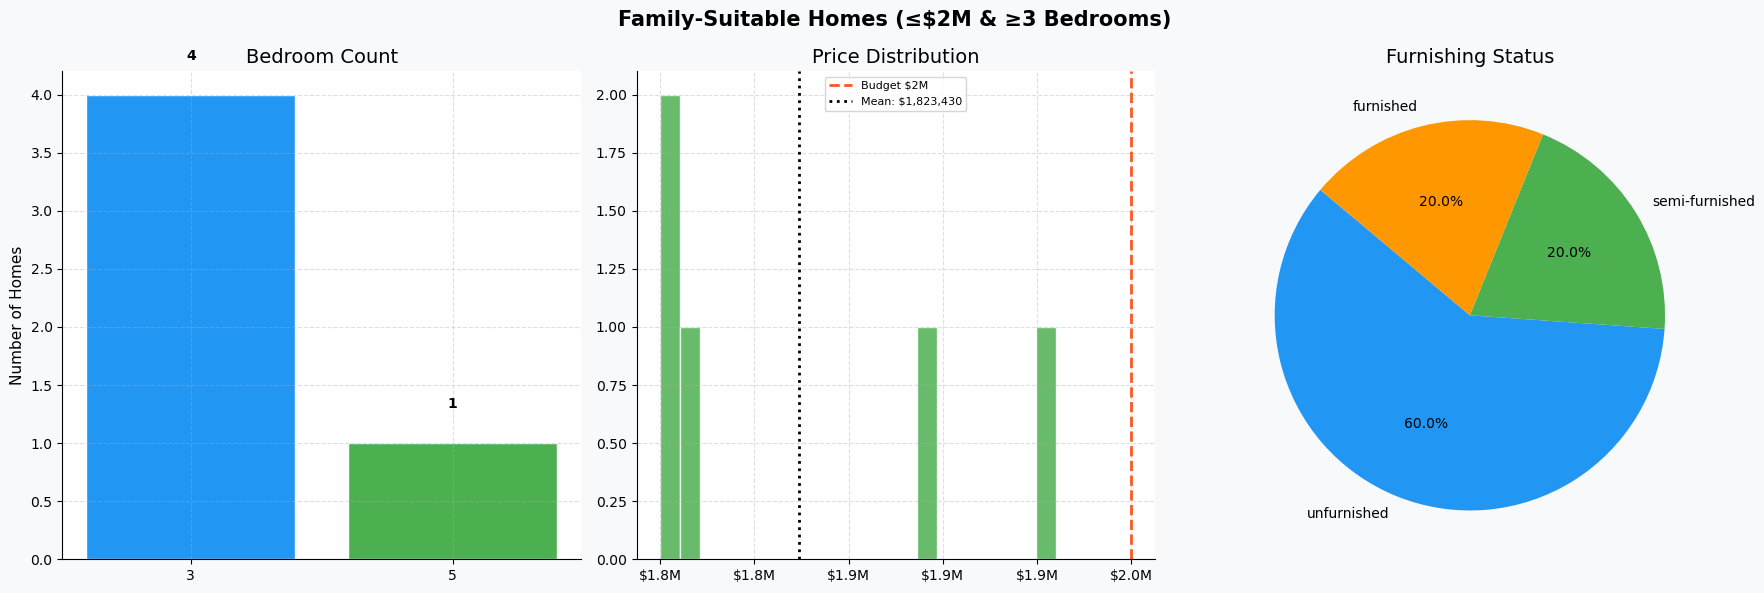

Conclusion: 5 out of 545 homes (0.9%) are within budget and have ≥3 bedrooms.


In [21]:
family_df = budget_df[budget_df['bedrooms'] >= 3]
print(f"Homes within budget AND ≥3 bedrooms : {len(family_df)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Family-Suitable Homes (≤$2M & ≥3 Bedrooms)", fontsize=15, fontweight='bold')

# Bedroom distribution
bc = family_df['bedrooms'].value_counts().sort_index()
axes[0].bar(bc.index.astype(str), bc.values, color=PALETTE, edgecolor='white')
axes[0].set_title('Bedroom Count')
axes[0].set_ylabel('Number of Homes')
for bar, val in zip(axes[0].patches, bc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(val), ha='center', fontweight='bold')

# Price histogram
axes[1].hist(family_df['price'], bins=20, color=COLOR_OK, edgecolor='white', alpha=0.85)
axes[1].axvline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=2, label='Budget $2M')
axes[1].axvline(family_df['price'].mean(), color='black', linestyle=':', linewidth=2,
                label=f"Mean: ${family_df['price'].mean():,.0f}")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[1].set_title('Price Distribution')
axes[1].legend(fontsize=8)

# Furnishing pie
fc = family_df['furnishingstatus'].value_counts()
axes[2].pie(fc.values, labels=fc.index, autopct='%1.1f%%', startangle=140,
            colors=PALETTE[:len(fc)], textprops={'fontsize':10})
axes[2].set_title('Furnishing Status')

plt.tight_layout()
plt.savefig('family_suitable_homes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Conclusion: {len(family_df)} out of {len(df)} homes ({len(family_df)/len(df)*100:.1f}%) are within budget and have ≥3 bedrooms.")


---
## 10.  Comprehensive Summary Dashboard

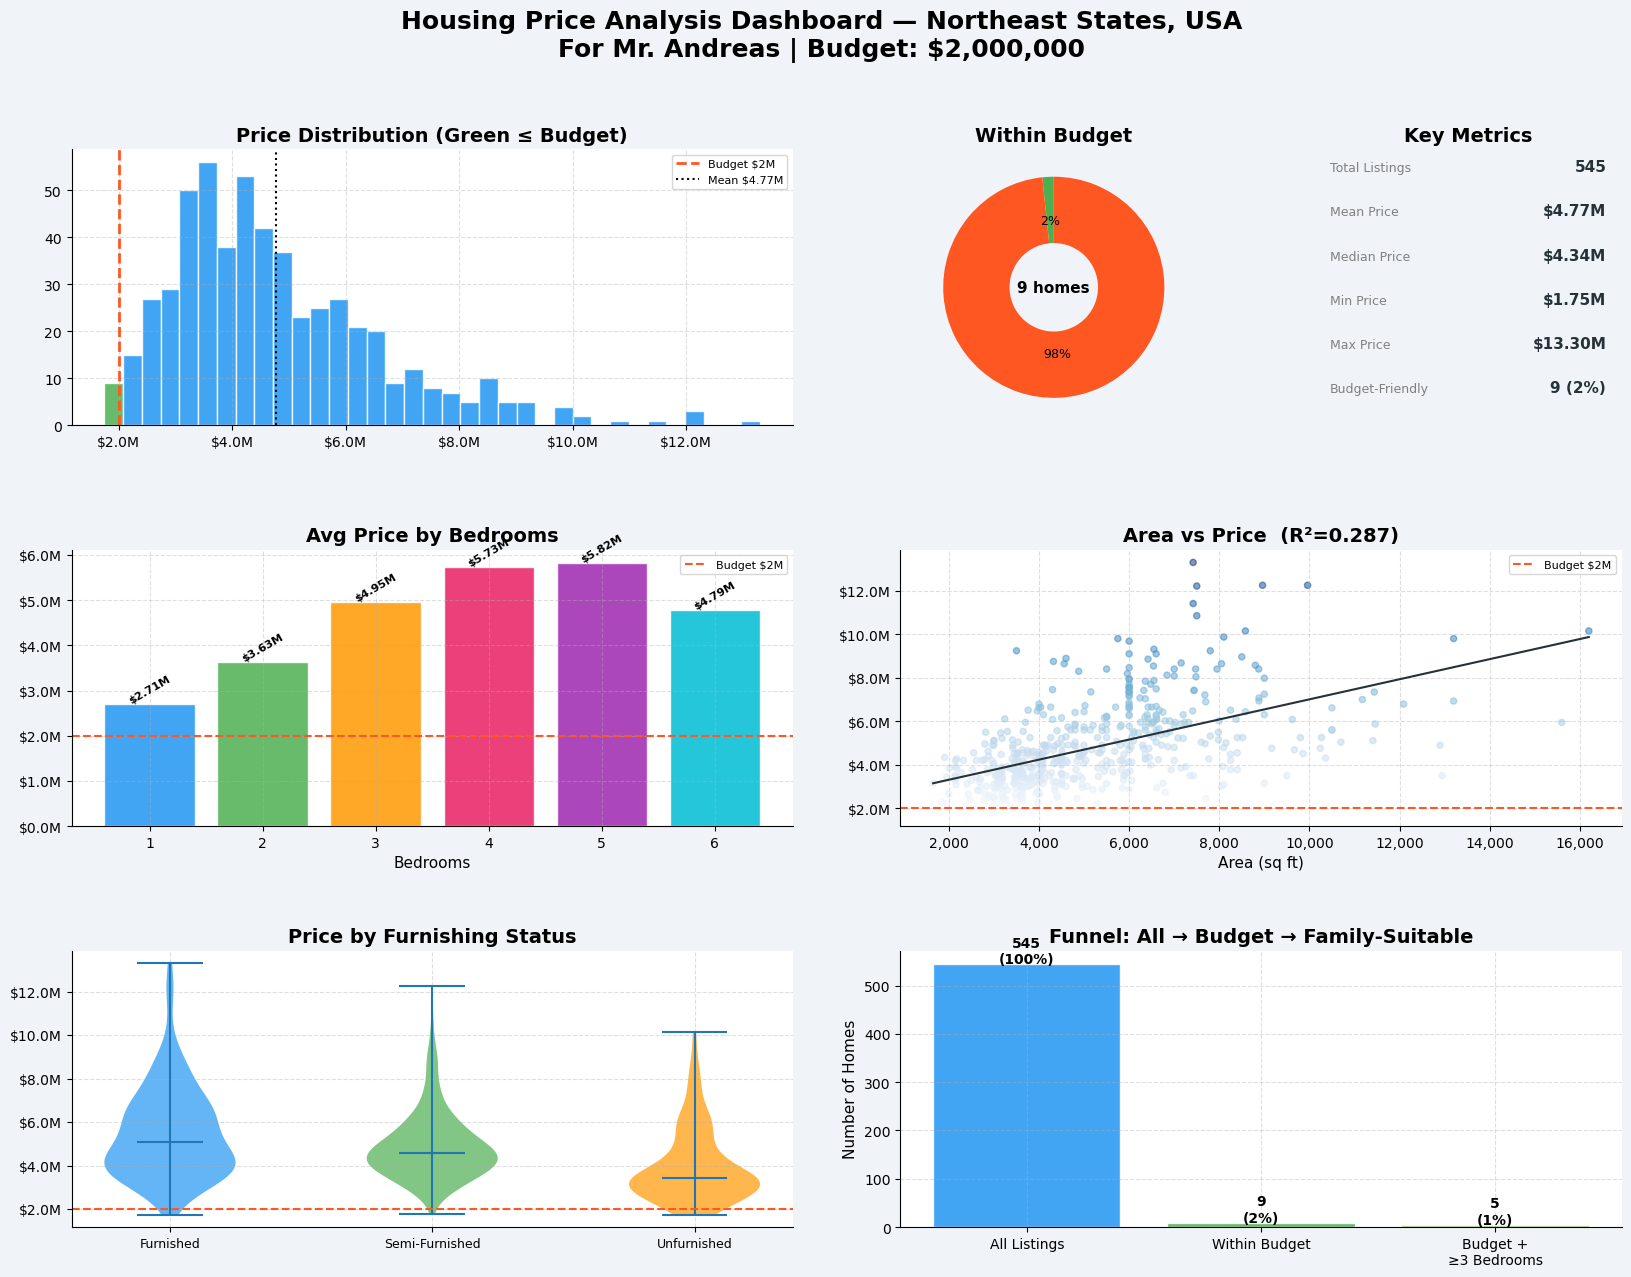

 Summary dashboard saved.


In [26]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#F0F4F8')
fig.suptitle('Housing Price Analysis Dashboard — Northeast States, USA\nFor Mr. Andreas | Budget: $2,000,000',
             fontsize=18, fontweight='bold', y=0.98)

gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Price Histogram ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
n, bins, patches = ax1.hist(df['price'], bins=35, edgecolor='white', alpha=0.85)
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(COLOR_OK if left <= BUDGET else COLOR_MAIN)
ax1.axvline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=2, label=f'Budget $2M')
ax1.axvline(df['price'].mean(), color='black', linestyle=':', linewidth=1.5, label=f"Mean ${df['price'].mean()/1e6:.2f}M")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax1.set_title('Price Distribution (Green ≤ Budget)', fontweight='bold')
ax1.legend(fontsize=8)

# ── Panel 2: Budget Donut ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
within_n = len(df[df['price'] <= BUDGET])
above_n  = len(df) - within_n
wedges, texts, autotexts = ax2.pie(
    [within_n, above_n],
    colors=[COLOR_OK, COLOR_WARN], autopct='%1.0f%%',
    startangle=90, wedgeprops=dict(width=0.6),
    textprops={'fontsize': 9}
)
ax2.set_title('Within Budget', fontweight='bold')
ax2.text(0, 0, f'{within_n} homes', ha='center', va='center', fontsize=11, fontweight='bold')

# ── Panel 3: Stats KPIs ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
ax3.axis('off')
kpis = [
    ('Total Listings',  f'{len(df)}'),
    ('Mean Price',      f"${df['price'].mean()/1e6:.2f}M"),
    ('Median Price',    f"${df['price'].median()/1e6:.2f}M"),
    ('Min Price',       f"${df['price'].min()/1e6:.2f}M"),
    ('Max Price',       f"${df['price'].max()/1e6:.2f}M"),
    ('Budget-Friendly', f'{within_n} ({within_n/len(df)*100:.0f}%)'),
]
for i, (k, v) in enumerate(kpis):
    y = 0.92 - i * 0.16
    ax3.text(0.05, y, k,    transform=ax3.transAxes, fontsize=9,  color='gray')
    ax3.text(0.95, y, v,    transform=ax3.transAxes, fontsize=11, fontweight='bold', ha='right', color=COLOR_DARK)
ax3.set_title('Key Metrics', fontweight='bold')

# ── Panel 4: Price by Bedrooms ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
bed_means = df.groupby('bedrooms')['price'].mean()
bars = ax4.bar(bed_means.index.astype(str), bed_means.values, color=PALETTE, edgecolor='white', alpha=0.85)
ax4.axhline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=1.5, label='Budget $2M')
for bar, val in zip(bars, bed_means.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15000,
             f'${val/1e6:.2f}M', ha='center', fontsize=8, fontweight='bold', rotation=30)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax4.set_xlabel('Bedrooms')
ax4.set_title('Avg Price by Bedrooms', fontweight='bold')
ax4.legend(fontsize=8)

# ── Panel 5: Area vs Price Scatter ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2:])
ax5.scatter(df['area'], df['price'], c=df['price'], cmap='Blues', alpha=0.5, s=20)
m, b, r, _, _ = stats.linregress(df['area'], df['price'])
xl = np.linspace(df['area'].min(), df['area'].max(), 200)
ax5.plot(xl, m*xl+b, color=COLOR_DARK, linewidth=1.5)
ax5.axhline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=1.5, label='Budget $2M')
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax5.set_xlabel('Area (sq ft)')
ax5.set_title(f'Area vs Price  (R²={r**2:.3f})', fontweight='bold')
ax5.legend(fontsize=8)

# ── Panel 6: Furnishing violin ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
furn_order2 = ['furnished','semi-furnished','unfurnished']
fdata = [df[df['furnishingstatus']==f]['price'].values for f in furn_order2]
parts2 = ax6.violinplot(fdata, positions=[1,2,3], showmedians=True)
for i, pc in enumerate(parts2['bodies']):
    pc.set_facecolor(PALETTE[i]); pc.set_alpha(0.7)
ax6.axhline(BUDGET, color=COLOR_WARN, linestyle='--', linewidth=1.5)
ax6.set_xticks([1,2,3])
ax6.set_xticklabels(['Furnished','Semi-Furnished','Unfurnished'], fontsize=9)
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax6.set_title('Price by Furnishing Status', fontweight='bold')

# ── Panel 7: Family homes bar ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2:])
categories2 = ['All Listings', 'Within Budget', 'Budget +\n≥3 Bedrooms']
counts2 = [len(df), within_n, len(budget_df[budget_df['bedrooms'] >= 3])]
colors2 = [COLOR_MAIN, COLOR_OK, '#8BC34A']
bars2 = ax7.bar(categories2, counts2, color=colors2, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, counts2):
    pct = val/len(df)*100
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             f'{val}\n({pct:.0f}%)', ha='center', fontsize=10, fontweight='bold')
ax7.set_ylabel('Number of Homes')
ax7.set_title('Funnel: All → Budget → Family-Suitable', fontweight='bold')

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Summary dashboard saved.")


---
## 11.  Conclusions & Recommendations

###  Key Findings

| # | Finding |
|---|---------|
| 1 | The housing price distribution is **right-skewed**, with most homes priced below $6M. |
| 2 | **9** homes fall within Mr. Andreas' $2M budget, representing approximately **1.7%** of the dataset. |
| 3 | After removing outliers via IQR, the dataset becomes cleaner and more representative. |
| 4 | The avarage market price of homes is **$4.3M**. |
| 5 | $2M budget is **suitable for a family of four**, the house have at least **3 bedrooms**. |
| 6 | **Bedrooms, stories, and amenities** significantly impact price (ANOVA p < 0.05). |

###  Recommendation for Mr. Andreas

Based on the analysis:

- **5** homes are within the $2M budget **and** have at least 3 bedrooms — suitable for a family of four.
- Semi-furnished homes in the budget range offer the best value.
- Homes without a preferred area tag or air conditioning tend to be more affordable while still meeting family needs.
- **Action:** Focus search on 3-bedroom, semi-furnished homes between **$1.5M–$2.0M** that are near the main road.

> *This analysis provides a strong foundation for Mr. Andreas to make a confident, data-driven housing decision.*


In [24]:
# Final numbers for the conclusion
within_n     = len(df[df['price'] <= BUDGET])
pct_within   = within_n / len(df) * 100
family_count = len(df[(df['price'] <= BUDGET) & (df['bedrooms'] >= 3)])

print("=" * 50)
print("  FINAL RECOMMENDATION SUMMARY")
print("=" * 50)
print(f"  Budget              : ${BUDGET:>12,.0f}")
print(f"  Homes within budget : {within_n:>6} ({pct_within:.1f}%)")
print(f"  Family-suitable     : {family_count:>6} (≥3 bedrooms)")
print(f"  Recommended range   : $1.5M – $2.0M")
print(f"  Best furnishing     : Semi-furnished")
print("=" * 50)


  FINAL RECOMMENDATION SUMMARY
  Budget              : $   2,000,000
  Homes within budget :      9 (1.7%)
  Family-suitable     :      5 (≥3 bedrooms)
  Recommended range   : $1.5M – $2.0M
  Best furnishing     : Semi-furnished
